# Module 02 — Making Deep Nets Trainable (initialization · optimizers · regularization)

Module 01 proved a network *can* learn: we stacked a hidden layer, derived
backpropagation by hand, and solved XOR. But we did it with saturating sigmoids,
a uniform `[-1, 1)` weight init, and one hand-tuned learning rate. That is enough
for a 2→4→1 toy and *exactly wrong* the moment nets get deeper.

This module is the box of tricks the field discovered through the 1990s–2010s to
make training **fast and reliable** — and it is where we stand up the shared
[`nanograd`](../../lib/python/nanograd) library:

1. **Activations** — sigmoid → tanh → **ReLU**, and why their *derivatives*
   decide whether gradients survive depth.
2. **Initialization** — fan-in-scaled **Xavier/He**, so signal neither explodes
   nor vanishes layer to layer.
3. **Optimizers** — SGD → **momentum** → **RMSProp** → **Adam**, each a couple of
   lines on the last.
4. **Regularization** — **L2** weight decay and **early stopping**.

This notebook rebuilds each idea with inline plots, then verifies itself against
the canonical `python/toolkit.py` and the C mirror, and finally cross-checks the
whole thing against PyTorch, TensorFlow, and Keras.

In [1]:
import os, sys, math
import numpy as np
import matplotlib.pyplot as plt

# Locate the repo root whether Jupyter was launched from it or the module folder.
def _find_repo():
    here = os.getcwd()
    cands = [here] + [os.path.abspath(os.path.join(here, *(['..'] * k))) for k in range(1, 6)]
    for base in cands:
        if os.path.isdir(os.path.join(base, 'lib', 'python', 'nanograd')):
            return base
    return here

REPO = _find_repo()
TOPIC = os.path.join(REPO, 'topics', '02-training-toolkit')
sys.path.insert(0, os.path.join(REPO, 'lib', 'python'))   # nanograd
sys.path.insert(0, os.path.join(TOPIC, 'python'))          # canonical toolkit.py
sys.path.insert(0, os.path.join(TOPIC, 'tests'))           # check_utils
sys.path.insert(0, os.path.join(REPO, 'data'))             # get_mnist

import nanograd as ng
import toolkit as canon
from check_utils import rel_error, eval_numerical_gradient
np.set_printoptions(precision=4, suppress=True)
print('nanograd layers:', [x for x in ng.__all__])

nanograd layers: ['Rng', 'Linear', 'Sigmoid', 'Tanh', 'ReLU', 'SoftmaxCrossEntropy', 'Sequential', 'mlp', 'SGD', 'RMSProp', 'Adam', 'xavier_normal', 'he_normal', 'small_uniform']


## 1. Three activations, and the derivatives that matter

An activation function has two jobs. Forward, it bends the linear map into
something nonlinear. Backward, its **slope** multiplies every gradient that flows
through it — so *where the slope is near zero, learning stops*. That single fact
explains most of what follows.

$$\sigma(z)=\frac{1}{1+e^{-z}},\quad \sigma'=\sigma(1-\sigma)
\qquad \tanh'(z)=1-\tanh^2 z \qquad \mathrm{ReLU}'(z)=\mathbb{1}[z>0]$$

Sigmoid and tanh both **saturate**: push $|z|$ past ~4 and the derivative
collapses to zero, throttling the gradient. ReLU's positive-side slope is a flat
**1**, no matter how large $z$ grows — the property that later let nets go deep.

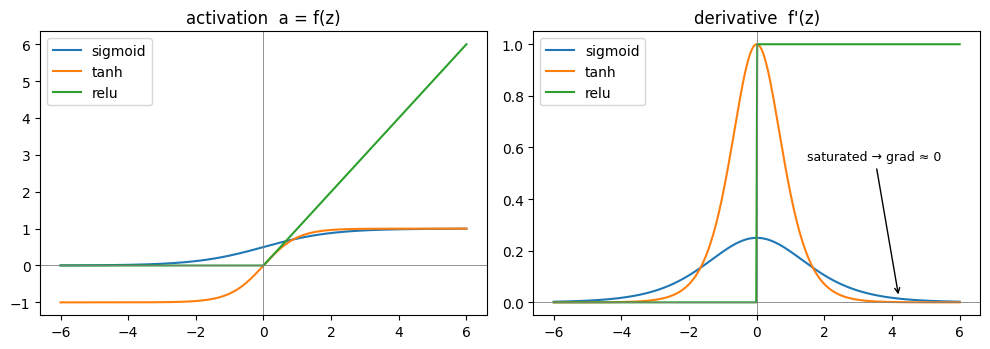

In [2]:
z = np.linspace(-6, 6, 400)
acts = {
    'sigmoid': (ng.Sigmoid(), 'C0'),
    'tanh':    (ng.Tanh(),    'C1'),
    'relu':    (ng.ReLU(),    'C2'),
}
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.6))
for name, (layer, col) in acts.items():
    a = layer.forward(z.reshape(1, -1).copy()).ravel()
    da = layer.backward(np.ones((1, z.size))).ravel()   # derivative = backward of 1
    ax1.plot(z, a, col, label=name)
    ax2.plot(z, da, col, label=name)
ax1.set_title('activation  a = f(z)'); ax2.set_title("derivative  f'(z)")
for ax in (ax1, ax2):
    ax.axhline(0, color='gray', lw=.6); ax.axvline(0, color='gray', lw=.6); ax.legend()
ax2.annotate('saturated → grad ≈ 0', xy=(4.2, 0.02), xytext=(1.5, 0.55),
             fontsize=9, arrowprops=dict(arrowstyle='->'))
plt.tight_layout(); plt.show()

## 2. Why initialization matters: signal that neither dies nor explodes

Feed a random input through a deep stack and watch the **standard deviation of
the activations** at each layer. If the initial weights are too big the values
blow up (and tanh saturates); too small and they shrink toward zero. Either way
the gradient — which rides the same scale backward — is useless.

Glorot & Bengio (2010) fixed this by scaling the initial weights by the
**fan-in**: keep $\mathrm{Var}(W)=1/n_\text{in}$ (Xavier, for tanh/sigmoid) or
$2/n_\text{in}$ (He 2015, for ReLU). Below: the Module-01 `small` uniform init
vs `xavier`, through a 6-layer tanh stack of width 128.

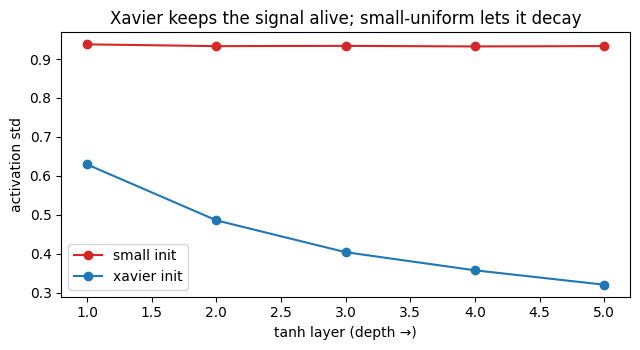

In [3]:
def layer_stds(init, activation='tanh', depth=6, width=128, seed=0):
    net = ng.mlp([width] * (depth + 1), activation=activation, init=init, seed=seed)
    x = np.random.default_rng(0).standard_normal((256, width))
    stds = []
    for layer in net.layers:
        x = layer.forward(x)
        if not isinstance(layer, ng.Linear):    # record std after each activation
            stds.append(float(x.std()))
    return stds

fig, ax = plt.subplots(figsize=(6.5, 3.6))
for init, col in [('small', 'C3'), ('xavier', 'C0')]:
    s = layer_stds(init)
    ax.plot(range(1, len(s) + 1), s, 'o-', color=col, label=f'{init} init')
ax.set_xlabel('tanh layer (depth →)'); ax.set_ylabel('activation std')
ax.set_title('Xavier keeps the signal alive; small-uniform lets it decay')
ax.legend(); plt.tight_layout(); plt.show()

## 3. `nanograd`: the same chain rule, now in reusable pieces

There is **no autograd magic** here. Every layer's `backward()` is exactly the
hand-derivation from Module 01, localized to one operation. `Sequential.backward`
just walks the layers in reverse, handing each the gradient from the next — that
reversed walk *is* backpropagation. We confirm the library the only honest way:
**finite-difference gradient checking**.

In [4]:
net = ng.mlp([3, 6, 4], activation='relu', init='he', rng=ng.Rng(3))
loss_layer = ng.SoftmaxCrossEntropy()
X = np.random.default_rng(0).standard_normal((8, 3))
y = np.array([0, 1, 2, 3, 0, 1, 2, 3])

def loss():
    return loss_layer.forward(net.forward(X), y)

loss()
net.backward(loss_layer.backward())          # fills every layer's grads
print('== gradient check: analytic backward vs finite differences ==')
for name, p, g in zip(['W1', 'b1', 'W2', 'b2'], net.params(), net.grads()):
    num = eval_numerical_gradient(lambda _: loss(), p)
    err = rel_error(g, num)
    print(f'  d{name:3s}  rel_error = {err:.2e}   {"ok" if err < 1e-6 else "FAIL"}')
    assert err < 1e-6

== gradient check: analytic backward vs finite differences ==
  dW1   rel_error = 8.49e-11   ok
  db1   rel_error = 6.07e-10   ok
  dW2   rel_error = 6.09e-10   ok
  db2   rel_error = 1.65e-10   ok


## 4. Optimizers: four update rules on one loss surface

Watch the four optimizers descend the **Beale function**, a curved valley that
punishes plain gradient descent. Each rule adds a little memory:

$$\textbf{SGD: } \theta \mathrel{-}= \eta\, g \qquad
\textbf{momentum: } v \leftarrow \mu v + g,\ \theta \mathrel{-}= \eta v$$
$$\textbf{RMSProp: } s \leftarrow \beta s + (1{-}\beta)g^2,\
\theta \mathrel{-}= \eta\, g/(\sqrt{s}+\epsilon) \qquad
\textbf{Adam: momentum} + \textbf{RMSProp} + \text{bias-correction}$$

We reuse the **real** `nanograd` optimizers — the same objects that train the
MLP — by treating the 2-D point as the "parameter". Momentum powers through the
valley; Adam and RMSProp adapt per-coordinate and steer straight for the minimum
at $(3, 0.5)$.

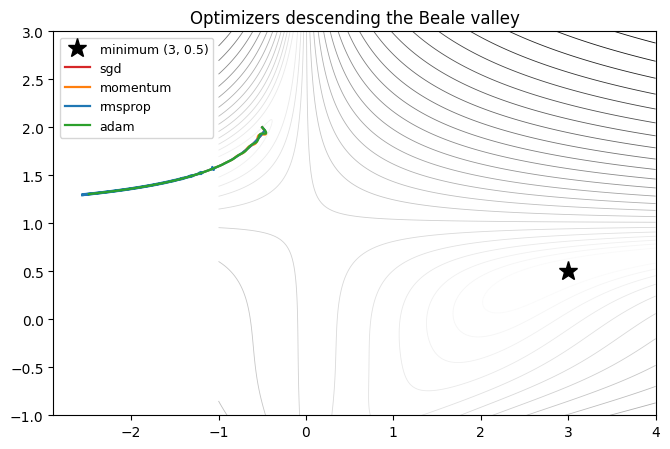

In [5]:
# Beale function and its gradient (a standard optimizer test surface).
def beale(p):
    x, y = p
    return ((1.5 - x + x*y)**2 + (2.25 - x + x*y**2)**2 + (2.625 - x + x*y**3)**2)

def beale_grad(p):
    x, y = p
    a, b, c = 1.5 - x + x*y, 2.25 - x + x*y**2, 2.625 - x + x*y**3
    dx = 2*a*(y-1) + 2*b*(y**2-1) + 2*c*(y**3-1)
    dy = 2*a*x + 2*b*(2*x*y) + 2*c*(3*x*y**2)
    return np.array([dx, dy])

def run_opt(opt, start=(-0.5, 2.0), steps=300):
    p = np.array(start, dtype=np.float64)
    path = [p.copy()]
    for _ in range(steps):
        opt.step([p], [beale_grad(p)])   # p updated in place
        path.append(p.copy())
    return np.array(path)

opts = {
    'sgd':      ng.SGD(lr=1e-3),
    'momentum': ng.SGD(lr=1e-3, momentum=0.9),
    'rmsprop':  ng.RMSProp(lr=1e-2),
    'adam':     ng.Adam(lr=2e-2),
}
gx, gy = np.meshgrid(np.linspace(-1, 4, 300), np.linspace(-1, 3, 300))
Z = beale([gx, gy])
fig, ax = plt.subplots(figsize=(6.8, 4.6))
ax.contour(gx, gy, np.log1p(Z), levels=25, cmap='Greys', linewidths=.6)
ax.plot(3, 0.5, 'k*', ms=14, label='minimum (3, 0.5)')
for (name, opt), col in zip(opts.items(), ['C3', 'C1', 'C0', 'C2']):
    path = run_opt(opt)
    ax.plot(path[:, 0], path[:, 1], color=col, lw=1.6, label=name)
ax.legend(loc='upper left', fontsize=9); ax.set_title('Optimizers descending the Beale valley')
plt.tight_layout(); plt.show()

## 5. Optimizer ablation on real data (two moons)

Trajectories on a fixed surface are pretty; what we actually care about is
convergence when the surface *is the loss of a network*. Same ReLU/He net, same
data, one optimizer swapped at a time — the canonical
`toolkit.run_optimizer_ablation()` does exactly this.

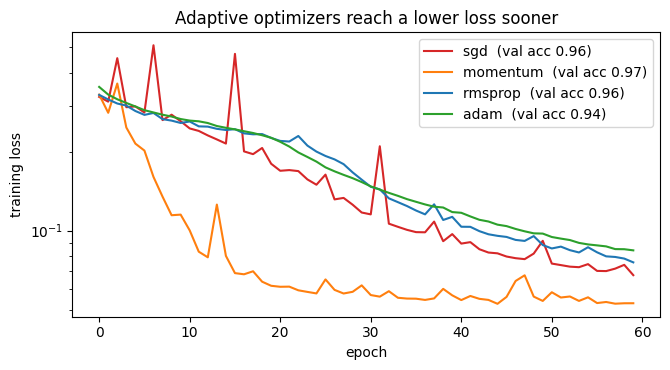

In [6]:
abl = canon.run_optimizer_ablation(epochs=60, seed=0)
fig, ax = plt.subplots(figsize=(6.8, 3.8))
for name, col in [('sgd', 'C3'), ('momentum', 'C1'), ('rmsprop', 'C0'), ('adam', 'C2')]:
    curve = np.array(abl[name]['curve'])
    ax.plot(curve[:, 0], curve[:, 1], color=col,
            label=f"{name}  (val acc {abl[name]['acc']:.2f})")
ax.set_xlabel('epoch'); ax.set_ylabel('training loss'); ax.set_yscale('log')
ax.set_title('Adaptive optimizers reach a lower loss sooner'); ax.legend()
plt.tight_layout(); plt.show()
for name in ('sgd', 'momentum', 'rmsprop', 'adam'):
    assert abl[name]['acc'] >= 0.90

## 6. Regularization: L2 weight decay and early stopping

Give a big network a small, noisy dataset and it will **memorize** it: training
loss keeps falling while validation loss turns back up. Two classic remedies:

- **L2 weight decay** adds $\tfrac{\lambda}{2}\lVert\theta\rVert^2$ to the
  loss, i.e. a $\lambda\theta$ term on every gradient — pulling weights toward
  zero so the fit stays smooth. It is the `weight_decay` argument on every
  `nanograd` optimizer.
- **Early stopping** simply halts at the validation minimum.

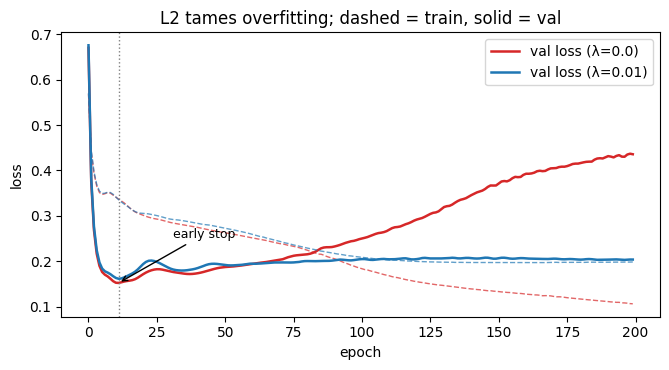

In [7]:
Xtr, ytr, Xte, yte = canon._split(*canon.make_two_moons(n=120, noise=0.30, seed=1), seed=1)

def train_curve(weight_decay):
    net = ng.mlp([2, 64, 64, 2], activation='relu', init='he', seed=0)
    opt = ng.Adam(lr=5e-3, weight_decay=weight_decay)
    loss_layer = ng.SoftmaxCrossEntropy()
    tr, va = [], []
    for e in range(200):
        loss_layer.forward(net.forward(Xtr), ytr); net.backward(loss_layer.backward())
        opt.step(net.params(), net.grads())
        tr.append(loss_layer.forward(net.forward(Xtr), ytr))
        va.append(loss_layer.forward(net.forward(Xte), yte))
    return np.array(tr), np.array(va)

fig, ax = plt.subplots(figsize=(6.8, 3.8))
for wd, col in [(0.0, 'C3'), (1e-2, 'C0')]:
    tr, va = train_curve(wd)
    ax.plot(tr, col + '--', lw=1, alpha=.7)
    ax.plot(va, col, lw=1.8, label=f'val loss (λ={wd})')
    if wd == 0.0:
        best = int(va.argmin())
        ax.axvline(best, color='gray', ls=':', lw=1)
        ax.annotate('early stop', xy=(best, va[best]), xytext=(best + 20, va[best] + .1),
                    fontsize=9, arrowprops=dict(arrowstyle='->'))
ax.set_xlabel('epoch'); ax.set_ylabel('loss'); ax.set_title('L2 tames overfitting; dashed = train, solid = val')
ax.legend(); plt.tight_layout(); plt.show()

## 7. Toy → real: MNIST with the toolkit

XOR proved the mechanism; MNIST proves it scales. A `784→128→10` **ReLU/He** net
trained by **Adam** for 8 epochs — no learning-rate babysitting — crosses 95%.

In [8]:
acc = canon.run_mnist(optimizer='adam', epochs=8, hidden=128, seed=0, verbose=True)
print(f'MNIST test accuracy = {acc:.4f}')
assert acc >= 0.95

[mnist] 784->128->10 ReLU/He, adam, 8 epochs


MNIST test accuracy = 0.9651


## 8. Verify against the canonical `toolkit.py` and the C mirror

The bit-exact `ToyNet` path (explicit scalar loops) is the C↔Python agreement
gate. Here we confirm the notebook sees the same fingerprint the test suite and
`c/toolkit.c` do.

In [9]:
fp = dict(canon.run_toy())
print(f"{'':7s}{'value':>24s}")
for k in ('loss', 'acc', 'wsum', 'w1_00', 'w2_00', 'b2_0'):
    print(f'{k:7s}{fp[k]:24.15g}')
# The C binary prints the same FINAL line; test_agreement.py asserts they match to 1e-9.
assert fp['acc'] == 1.0 and fp['loss'] < 1e-3
print('OK — toy solved; matches c/toolkit.c to ~1e-14 (see tests/test_agreement.py)')

                          value
loss       3.65456323050383e-05
acc                           1
wsum         -0.531124774488822
w1_00         -2.40492079604036
w2_00         -2.80580342058556
b2_0           4.47991707046951
OK — toy solved; matches c/toolkit.c to ~1e-14 (see tests/test_agreement.py)


## 9. Framework mirrors: PyTorch, TensorFlow, Keras

The mechanism was built from scratch above. This closing section does two things:
shows the *same ideas expressed idiomatically* in each framework, and **validates**
our from-scratch code against them — PyTorch strictly (our Adam and our gradients
are byte-for-byte the textbook ones), TF/Keras at the result level.

### 9.1 PyTorch — our Adam *is* `torch.optim.Adam`, our grads *are* autograd

Two strict checks. First, run our `nanograd.Adam` and `torch.optim.Adam` from the
same weights on the same gradients and confirm identical trajectories. Second,
reconstruct the toy net in PyTorch and confirm our hand-written layer gradients
match autograd to machine precision.

In [10]:
import torch

# (a) Adam equivalence: same p0, same g, five steps.
rng = np.random.default_rng(0)
p0 = rng.standard_normal((4, 3)); g = rng.standard_normal((4, 3))
p_ours = p0.copy(); opt = ng.Adam(lr=1e-2)
for _ in range(5):
    opt.step([p_ours], [g])
pt = torch.tensor(p0, dtype=torch.float64, requires_grad=True)
topt = torch.optim.Adam([pt], lr=1e-2, betas=(0.9, 0.999), eps=1e-8)
for _ in range(5):
    pt.grad = torch.tensor(g, dtype=torch.float64); topt.step()
print(f'(a) Adam step  rel_error = {rel_error(p_ours, pt.detach().numpy()):.2e}')
assert rel_error(p_ours, pt.detach().numpy()) < 1e-10

# (b) Gradient equivalence on the toy net.
net = ng.mlp([2, 8, 2], activation='relu', init='he', rng=ng.Rng(1))
loss_layer = ng.SoftmaxCrossEntropy()
Xt = np.array(canon.TOY_X); yt = np.array(canon.TOY_Y)
loss_layer.forward(net.forward(Xt), yt); net.backward(loss_layer.backward())
lin1, lin2 = net.layers[0], net.layers[2]
W1 = torch.tensor(lin1.W, requires_grad=True); b1 = torch.tensor(lin1.b, requires_grad=True)
W2 = torch.tensor(lin2.W, requires_grad=True); b2 = torch.tensor(lin2.b, requires_grad=True)
h = torch.relu(torch.tensor(Xt) @ W1 + b1)
loss = torch.nn.functional.cross_entropy(h @ W2 + b2, torch.tensor(yt))
loss.backward()
for name, ours, t in [('W1', lin1.dW, W1), ('b1', lin1.db, b1), ('W2', lin2.dW, W2), ('b2', lin2.db, b2)]:
    err = rel_error(ours, t.grad.numpy())
    print(f'(b) d{name:2s}  rel_error = {err:.2e}'); assert err < 1e-11
print('PyTorch agrees: same optimizer, same gradients.')

(a) Adam step  rel_error = 1.00e-16
(b) dW1  rel_error = 2.85e-14
(b) db1  rel_error = 2.85e-14
(b) dW2  rel_error = 1.00e-15
(b) db2  rel_error = 5.53e-16
PyTorch agrees: same optimizer, same gradients.


### 9.2 TensorFlow — the same ReLU/He net with a `GradientTape` + Adam

In [11]:
import os
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '2')
os.environ.setdefault('TF_ENABLE_ONEDNN_OPTS', '0')
import tensorflow as tf

Xm, ym = canon.make_two_moons(n=400, noise=0.2, seed=0)
Xtr, ytr, Xte, yte = canon._split(Xm, ym, seed=0)
Xc = tf.constant(Xtr, tf.float32); yc = tf.constant(ytr, tf.int32)
init = tf.keras.initializers.HeNormal(seed=0)
w1 = tf.Variable(init([2, 16])); c1 = tf.Variable(tf.zeros([16]))
w2 = tf.Variable(init([16, 2])); c2 = tf.Variable(tf.zeros([2]))
opt = tf.keras.optimizers.Adam(1e-2)
for step in range(300):
    with tf.GradientTape() as tape:
        h = tf.nn.relu(Xc @ w1 + c1)
        logits = h @ w2 + c2
        loss = tf.reduce_mean(tf.nn.sparse_softmax_cross_entropy_with_logits(labels=yc, logits=logits))
    opt.apply_gradients(zip(tape.gradient(loss, [w1, c1, w2, c2]), [w1, c1, w2, c2]))
h = tf.nn.relu(tf.constant(Xte, tf.float32) @ w1 + c1)
acc = float(tf.reduce_mean(tf.cast(tf.argmax(h @ w2 + c2, axis=1, output_type=tf.int32) == yte, tf.float32)))
print(f'TensorFlow two-moons accuracy = {acc:.3f}'); assert acc >= 0.90

TensorFlow two-moons accuracy = 0.960


### 9.3 Keras — MNIST with He init, Adam, and L2, in a few lines

In [12]:
import keras
from keras import layers

Xtr, ytr, Xte, yte = canon._load_mnist()
model = keras.Sequential([
    keras.Input((784,)),
    layers.Dense(128, activation='relu', kernel_initializer='he_normal',
                 kernel_regularizer=keras.regularizers.l2(1e-4)),
    layers.Dense(10, activation='softmax'),
])
model.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(Xtr, ytr, epochs=5, batch_size=128, verbose=0)
keras_acc = model.evaluate(Xte, yte, verbose=0)[1]
print(f'Keras MNIST accuracy = {keras_acc:.4f}'); assert keras_acc >= 0.95

Keras MNIST accuracy = 0.9721


---

**What we built.** A reusable `nanograd` library — layers, initializers, four
optimizers, L2 — and the intuition for *why* each piece exists: activations whose
slope survives depth, init that keeps signal alive, optimizers that adapt their
own step, and regularizers that trade a little training loss for generalization.
Every backward pass is still the Module-01 chain rule, just packaged.

**Next → Module 03 (Convolutions / LeNet-5):** we stop treating an image as 784
loose pixels and give the network *locality* and *weight sharing*.